# Conditional Generative Model for Radio Galaxy Embeddings

Pipeline: **class label → NSF sample z ∈ ℝ²⁵⁶ → CNN decoder → 89×89 image**

Two components trained here:
1. **CNN Decoder** — `EmbeddingDecoder`: ℝ²⁵⁶ → ℝ^(89×89), trained with MSE loss against real images
2. **Conditional NSF** — `zuko.flows.NSF`: learns p(embedding | labels)

At generation time: sample z from NSF conditioned on a class label, decode z to an image.

In [ ]:
# Cell 1: Imports & Configuration (user-editable)
import sys
import copy
import math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import zuko
import umap
from pathlib import Path
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset

ROOT = Path("..").resolve()
sys.path.insert(0, str(ROOT / "src"))

CONFIG = {
    # Point to the run output directory (embeddings/ subdir is auto-detected)
    "base_dir":        ROOT / "outputs/run_enb0_pca_pond_step_wd_20260424_0019",
    "images_path":     ROOT / "data/images_filtered.npy",
    "labels_path":     ROOT / "data/labels_filtered.npy",
    # label_subset: 'classical' | 'classical_pure' | 'initial' | 'initial_pure' |
    #               'environment' | 'derived' | 'morphology' | 'all' | 'pure'
    # or a custom list of int indices into ALL_CLASS_NAMES
    "label_subset":    "initial",
    # ── Decoder ───────────────────────────────────────────────────────────────
    # use_projections: True  → decoder and NSF both operate on the PCA/MLP projection
    #                          (lower-dim, semantically rich, consistent with BYOL training)
    #                  False → decoder uses raw encoder features (higher-dim)
    "use_projections": True,
    # decoder_type: "flow" → flow-matching U-Net (sharp outputs, ~20 inference steps)
    #               "cnn"  → simple FC decoder (fast, blurrier)
    "decoder_type":    "flow",
    "flow_n_steps":    20,          # Euler integration steps at generation time
    # ── Training ──────────────────────────────────────────────────────────────
    "flow_epochs":     200,
    "decoder_epochs":  300,
    "decoder_lr":      1e-4,
    "decoder_patience": 40,
    "decoder_loss_alpha": 0.7,      # MSE weight for "cnn" decoder; (1-α) → L1
    "batch_size":      256,
    "lr":              3e-4,
    "n_flow_transforms": 8,
    "seed":            42,
    # ── Regularisation ────────────────────────────────────────────────────────
    "decoder_dropout":      0.3,    # CNN decoder only; set 0.0 to disable
    "decoder_weight_decay": 1e-4,
    "flow_weight_decay":    1e-5,
    "flow_feat_noise":      0.05,
}

# | label_subset      | Columns   | Classes                                                          |
# |-------------------|-----------|------------------------------------------------------------------|
# | "classical"       | 0–1       | FRI, FRII                                                        |
# | "classical_pure"  | 0–1       | FRI, FRII — sources with exactly one initial label               |
# | "initial"         | 0–4       | FRI, FRII, Hybrids, Spirals, Relaxed doubles                     |
# | "initial_pure"    | 0–4       | FRI, FRII, Hybrids, Spirals, Relaxed doubles — one initial label |
# | "environment"     | 16–19     | Cluster, Merger, Diffuse, Unknown                                |
# | "derived"         | computed  | Pure hybrid, FR hybrid, Curved FRI, Curved FRII, Straight+mHS   |
# | "morphology"      | 5–14      | C-curv … Restarted                                               |
# | "all"             | 0–19      | All 20 classes                                                   |
# | "pure"            | 0–19      | All 20 classes (single-label across all 20 only)                 |
#
# Derived label definitions (computed, not raw columns):
#   1. Pure hybrid    : col2 & ~col0 & ~col1
#   2. FR hybrid      : col2 & (col0 | col1)
#   3. Curved FRI     : col0 & (col5 | col6)
#   4. Curved FRII    : col1 & (col5 | col6)
#   5. Straight+mHS   : col10 & col11
LABEL_SUBSETS = {
    "classical":      [0, 1],
    "classical_pure": [0, 1],
    "initial":        list(range(0, 5)),
    "initial_pure":   list(range(0, 5)),
    "environment":    list(range(16, 20)),
    "derived":        None,  # computed from label combinations
    "morphology":     list(range(5, 15)),
    "all":            list(range(0, 20)),
    "pure":           list(range(0, 20)),
}

DERIVED_CLASS_NAMES = [
    'Pure hybrid',       # col2 & ~col0 & ~col1
    'FR hybrid',         # col2 & (col0 | col1)
    'Curved FRI',        # col0 & (col5 | col6)
    'Curved FRII',       # col1 & (col5 | col6)
    'Straight+multi-HS', # col10 & col11
]

ALL_CLASS_NAMES = [
    "FRI", "FRII", "Hybrids", "Spirals", "Relaxed doubles",        # 0-4  initial
    "C-curv", "S-curv", "Misalign", "Wings", "X-shaped",           # 5-9  morphology
    "Straight jets", "Multi hotspots", "Cont. jets", "Banding",    # 10-13
    "One-sided", "Restarted",                                       # 14-15
    "Cluster", "Merger", "Diffuse", "Unknown",                      # 16-19 environment
]

print("Config loaded.")
print(f"  Decoder:          {CONFIG['decoder_type']} | use_projections: {CONFIG['use_projections']}")
print(f"  Label subset:     {CONFIG['label_subset']}")
print(f"  Base dir:         {CONFIG['base_dir']}")

## Cell 2: Load Pre-Saved Embeddings

Loads `train/val/test_projections.npy` and `train/val/test_labels.npy` from the embeddings directory.
These are used directly for **NSF training** (no images needed).

In [20]:
# Cell 2: Load pre-saved embeddings and labels
_base   = Path(CONFIG["base_dir"])
emb_dir = _base / "embeddings" if (_base / "embeddings").is_dir() else _base

train_z = np.load(emb_dir / "train_projections.npy").astype(np.float32)
val_z   = np.load(emb_dir / "val_projections.npy").astype(np.float32)
test_z  = np.load(emb_dir / "test_projections.npy").astype(np.float32)

train_lbl_full = np.load(emb_dir / "train_labels.npy").astype(np.float32)
val_lbl_full   = np.load(emb_dir / "val_labels.npy").astype(np.float32)
test_lbl_full  = np.load(emb_dir / "test_labels.npy").astype(np.float32)

# Select label subset
label_subset = CONFIG["label_subset"]
if isinstance(label_subset, list):
    label_idx = label_subset
else:
    label_idx = LABEL_SUBSETS[label_subset]

# For "derived": compute 5 boolean combination columns
def _make_derived(y):
    c = lambda i: y[:, i].astype(bool)
    return np.stack([
        ( c(2) & ~c(0) & ~c(1)).astype(np.float32),   # Pure hybrid
        ( c(2) &  (c(0) | c(1))).astype(np.float32),  # FR hybrid
        ( c(0) &  (c(5) | c(6))).astype(np.float32),  # Curved FRI
        ( c(1) &  (c(5) | c(6))).astype(np.float32),  # Curved FRII
        (c(10) &   c(11)).astype(np.float32),          # Straight + multi-HS
    ], axis=1)

if label_subset == "derived":
    train_y = _make_derived(train_lbl_full)
    val_y   = _make_derived(val_lbl_full)
    test_y  = _make_derived(test_lbl_full)
    label_names_subset = DERIVED_CLASS_NAMES
else:
    train_y = train_lbl_full[:, label_idx]
    val_y   = val_lbl_full[:, label_idx]
    test_y  = test_lbl_full[:, label_idx]
    label_names_subset = [ALL_CLASS_NAMES[i] for i in label_idx]

n_labels = len(label_names_subset)

# Pure filtering — always define masks (all-True by default)
keep_train_mask = np.ones(len(train_lbl_full), dtype=bool)
keep_val_mask   = np.ones(len(val_lbl_full),   dtype=bool)
keep_test_mask  = np.ones(len(test_lbl_full),  dtype=bool)

if label_subset == "pure":
    keep_train_mask = train_lbl_full.sum(axis=1) == 1
    keep_val_mask   = val_lbl_full.sum(axis=1)   == 1
    keep_test_mask  = test_lbl_full.sum(axis=1)  == 1
    print(f"Pure filter (all 20)   : {keep_train_mask.sum()} train / {keep_val_mask.sum()} val / {keep_test_mask.sum()} test retained")
elif label_subset in ("classical_pure", "initial_pure"):
    keep_train_mask = train_lbl_full[:, 0:5].sum(axis=1) == 1
    keep_val_mask   = val_lbl_full[:, 0:5].sum(axis=1)   == 1
    keep_test_mask  = test_lbl_full[:, 0:5].sum(axis=1)  == 1
    print(f"Initial-pure filter    : {keep_train_mask.sum()} train / {keep_val_mask.sum()} val / {keep_test_mask.sum()} test retained")

train_z, train_y = train_z[keep_train_mask], train_y[keep_train_mask]
val_z,   val_y   = val_z[keep_val_mask],     val_y[keep_val_mask]
test_z,  test_y  = test_z[keep_test_mask],   test_y[keep_test_mask]

print(f"Embeddings dir:  {emb_dir}")
print(f"Label subset ({n_labels}): {label_names_subset}")
print(f"Train z: {train_z.shape} | Val z: {val_z.shape} | Test z: {test_z.shape}")
print(f"Train labels: {train_y.shape}")
print(f"Label prevalence (train):\n",
      dict(zip(label_names_subset, train_y.mean(axis=0).round(3))))

Embeddings dir:  /users/mbredber/p3_SUPLAT/outputs/run_enb0_pca_pond_step_wd_20260424_0019/embeddings
Label subset (5): ['FRI', 'FRII', 'Hybrids', 'Spirals', 'Relaxed doubles']
Train z: (5317, 187) | Val z: (1024, 187) | Test z: (1024, 187)
Train labels: (5317, 5)
Label prevalence (train):
 {'FRI': np.float32(0.317), 'FRII': np.float32(0.621), 'Hybrids': np.float32(0.096), 'Spirals': np.float32(0.018), 'Relaxed doubles': np.float32(0.047)}


## Cell 3: Align Embeddings with Images (for Decoder Training)

The decoder needs `(embedding, image)` pairs.

**Primary strategy** — load `train_idx.npy` / `val_idx.npy` saved alongside the embeddings,
then index the raw images with those. Fast, no GPU needed.

**Backup strategy** — if index files are missing (e.g. older BYOL runs), load the BYOL
checkpoint and re-extract projections from the current images via frozen inference.
Which path is taken is printed below.

In [ ]:
# Cell 3: Align embeddings with images
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

USE_PROJECTIONS = CONFIG.get("use_projections", True)
DECODER_TYPE    = CONFIG.get("decoder_type", "flow")

print("Loading images…")
all_images = np.load(CONFIG["images_path"])   # (N, 89, 89) uint8
print(f"  Images: {all_images.shape}, dtype={all_images.dtype}")

base_dir = Path(CONFIG["base_dir"])
emb_dir  = base_dir / "embeddings" if (base_dir / "embeddings").is_dir() else base_dir
data_dir = base_dir / "data"
ckpt_path = Path(CONFIG["byol_checkpoint"]) if "byol_checkpoint" in CONFIG \
            else base_dir / "byol_model_best.pt"
print(f"Embeddings dir:   {emb_dir}")

# idx files may be in embeddings/ (old runs) or data/ (current runs)
def _find_idx_dir(*dirs):
    for d in dirs:
        if all((d / f).exists() for f in ("train_idx.npy", "val_idx.npy", "test_idx.npy")):
            return d
    return None

idx_dir = _find_idx_dir(emb_dir, data_dir)

def _strip_compile_prefix(sd):
    p = "_orig_mod."
    return {k[len(p):] if k.startswith(p) else k: v for k, v in sd.items()} \
           if any(k.startswith(p) for k in sd) else sd

def infer_model_type(sd):
    keys = set(sd.keys())
    if any("online_encoder.features.1.0.block.0.0.weight" in k for k in keys): return "efficientnet-b0"
    if any("online_encoder.features.1.0.block.0.weight"   in k for k in keys): return "convnext-tiny"
    if any("online_encoder.layer1.0.conv1.weight"         in k for k in keys):
        proj = sd.get("online_projector.net.0.weight")
        return "resnet50" if (proj is not None and proj.shape[1] == 2048) else "resnet18"
    if any("online_encoder.conv1.weight" in k for k in keys): return "convnet"
    return None

def infer_projection_config(sd):
    mode = "pca" if "online_projector.mean_" in sd else "mlp"
    pred_w = sd.get("online_predictor.net.0.weight")
    return mode, int(pred_w.shape[1]) if pred_w is not None else 256

def prepare_pca_model(model, sd):
    from suplat.models.byol_models import PCAProjection, PredictionHead
    for prefix in ("online_projector", "target_projector"):
        proj = getattr(model, prefix, None)
        if not isinstance(proj, PCAProjection): continue
        for buf in ("mean_", "components_", "active_mask_"):
            key = f"{prefix}.{buf}"
            if key in sd: proj.register_buffer(buf, sd[key].clone())
        proj._fitted = True
    if model.online_predictor is None and "online_predictor.net.0.weight" in sd:
        proj_dim = sd["online_predictor.net.0.weight"].shape[1]
        hidden_dim, bn_momentum = model._predictor_config
        model.online_predictor = PredictionHead(
            in_dim=proj_dim, hidden_dim=hidden_dim, out_dim=proj_dim, bn_momentum=bn_momentum)

def patch_missing_active_mask(model, sd):
    from suplat.models.byol_models import PCAProjection
    for prefix in ("online_projector", "target_projector"):
        proj = getattr(model, prefix, None)
        if isinstance(proj, PCAProjection) and not hasattr(proj, "active_mask_"):
            n = proj.mean_.shape[0]
            proj.register_buffer("active_mask_", torch.ones(n, dtype=torch.bool))
            print(f"  [PCA] {prefix}: patched active_mask_ ({n} features)")

def load_byol_from_checkpoint(path, device):
    from suplat.models.byol_models import (
        BYOLEfficient, BYOLEfficientNetB0, BYOLPretrainedBackbone,
        create_resnet18_backbone, create_resnet50_backbone, create_convnext_tiny_backbone,
    )
    ckpt = torch.load(path, map_location=device)
    sd   = _strip_compile_prefix(ckpt["model_state_dict"])
    model_type          = infer_model_type(sd)
    proj_mode, proj_dim = infer_projection_config(sd)
    print(f"  model_type: {model_type!r} | projection: {proj_mode!r} dim={proj_dim}")
    if   model_type == "convnet":       model = BYOLEfficient(feature_compression_mode=proj_mode, projection_dim=proj_dim)
    elif model_type == "efficientnet-b0": model = BYOLEfficientNetB0(feature_compression_mode=proj_mode, projection_dim=proj_dim)
    elif model_type == "resnet18":
        bb, enc = create_resnet18_backbone(num_channels=1)
        model = BYOLPretrainedBackbone(bb, encoder_dim=enc, projection_dim=proj_dim, feature_compression_mode=proj_mode)
    elif model_type == "resnet50":
        bb, enc = create_resnet50_backbone(num_channels=1)
        model = BYOLPretrainedBackbone(bb, encoder_dim=enc, projection_dim=proj_dim, feature_compression_mode=proj_mode)
    elif model_type == "convnext-tiny":
        bb, enc = create_convnext_tiny_backbone(num_channels=1)
        model = BYOLPretrainedBackbone(bb, encoder_dim=enc, projection_dim=proj_dim, feature_compression_mode=proj_mode)
    else: raise ValueError(f"Could not detect model type from checkpoint")
    if proj_mode == "pca": prepare_pca_model(model, sd)
    model.load_state_dict(sd)
    if proj_mode == "pca": patch_missing_active_mask(model, sd)
    model.eval().to(device)
    for p in model.parameters(): p.requires_grad = False
    print(f"  BYOL loaded (epoch {ckpt['epoch']}, best_val_loss={ckpt.get('best_val_loss','?'):.4f})")
    return model

# BYOL is always loaded — needed for Cell 8 Mode A (encode real images)
print("Loading BYOL checkpoint…")
byol = load_byol_from_checkpoint(ckpt_path, device)

# ── Load or replicate split indices ───────────────────────────────────────────
if idx_dir is not None:
    print(f"Loading saved split indices from {idx_dir.name}/")
    train_idx = np.load(idx_dir / "train_idx.npy")
    val_idx   = np.load(idx_dir / "val_idx.npy")
    test_idx  = np.load(idx_dir / "test_idx.npy")
    train_emb = torch.from_numpy(np.load(emb_dir / "train_projections.npy").astype(np.float32))
    val_emb   = torch.from_numpy(np.load(emb_dir / "val_projections.npy").astype(np.float32))
    test_emb  = torch.from_numpy(np.load(emb_dir / "test_projections.npy").astype(np.float32))
else:
    print("Index files not found — replicating split from create_embeddings.py.")
    all_idx = np.arange(len(all_images))
    train_idx, temp_idx = train_test_split(all_idx, test_size=0.30, random_state=CONFIG["seed"])
    val_idx,   test_idx = train_test_split(temp_idx, test_size=0.50, random_state=CONFIG["seed"])
    def _extract_proj(img_array, bs=128):
        imgs_t = torch.from_numpy(img_array.astype(np.float32) / 255.0).unsqueeze(1)
        out = []
        with torch.no_grad():
            for (x,) in DataLoader(TensorDataset(imgs_t), batch_size=bs):
                out.append(byol.online_projector(byol.online_encoder(x.to(device))).cpu())
        return torch.cat(out)
    print("  Extracting projections…")
    train_emb = _extract_proj(all_images[train_idx])
    val_emb   = _extract_proj(all_images[val_idx])
    test_emb  = _extract_proj(all_images[test_idx])

# ── Image tensors (always needed for decoder training) ────────────────────────
# n_*: saved projections may be shorter than full split (drop_last=True with --compile)
# keep_*_mask from Cell 2 is sized to match the saved projections, so clip to that.
n_train, n_val, n_test = len(keep_train_mask), len(keep_val_mask), len(keep_test_mask)
train_imgs = torch.from_numpy(all_images[train_idx[:n_train]].astype(np.float32) / 255.0).unsqueeze(1)
val_imgs   = torch.from_numpy(all_images[val_idx[:n_val]  ].astype(np.float32)   / 255.0).unsqueeze(1)
test_imgs  = torch.from_numpy(all_images[test_idx[:n_test] ].astype(np.float32)  / 255.0).unsqueeze(1)

# ── Encoder features — only needed when use_projections=False ─────────────────
if not USE_PROJECTIONS:
    def _extract_feats(img_array, bs=128):
        imgs_t = torch.from_numpy(img_array.astype(np.float32) / 255.0).unsqueeze(1)
        out = []
        with torch.no_grad():
            for (x,) in DataLoader(TensorDataset(imgs_t), batch_size=bs):
                out.append(byol.online_encoder(x.to(device)).cpu())
        return torch.cat(out)
    print("Extracting raw encoder features for decoder…")
    _train_feats_raw = _extract_feats(all_images[train_idx])[:n_train]
    _val_feats_raw   = _extract_feats(all_images[val_idx])[:n_val]
    _test_feats_raw  = _extract_feats(all_images[test_idx])[:n_test]

# ── Apply label/pure filter mask from Cell 2 ──────────────────────────────────
train_imgs = train_imgs[keep_train_mask]
val_imgs   = val_imgs[keep_val_mask]
test_imgs  = test_imgs[keep_test_mask]
train_emb  = train_emb[keep_train_mask]
val_emb    = val_emb[keep_val_mask]
test_emb   = test_emb[keep_test_mask]

# ── Decoder conditioning: projections (default) or raw encoder features ────────
if USE_PROJECTIONS:
    train_feats = train_emb   # same tensor, projections are the decoder input
    val_feats   = val_emb
    test_feats  = test_emb
    print("Decoder input: PCA/MLP projections")
else:
    train_feats = _train_feats_raw[keep_train_mask]
    val_feats   = _val_feats_raw[keep_val_mask]
    test_feats  = _test_feats_raw[keep_test_mask]
    print("Decoder input: raw encoder features")

print(f"\nSplit sizes (after filter) — train: {train_feats.shape[0]} | val: {val_feats.shape[0]} | test: {test_feats.shape[0]}")
print(f"Decoder input dim: {train_feats.shape[1]}  |  NSF input dim: {train_emb.shape[1]}")

## Cell 4: Decoder Architecture

```
z (256) → Linear(512) → Linear(32×16×16) → reshape (B,32,16,16)
        → Upsample bilinear → (B,32,89,89)
        → Conv2d(32→1, 3×3) → Sigmoid → (B,1,89,89)
```

In [ ]:
# Cell 4: Decoder architectures
#
# Two options, selected by CONFIG["decoder_type"]:
#
#   "cnn"  — EmbeddingDecoder: simple FC → upsample chain.
#             Fast, low memory. Outputs are blurry because z has no spatial
#             structure and is only used at the bottleneck.
#
#   "flow" — FlowUNet: flow-matching velocity network.
#             A U-Net processes a noisy image x_t conditioned on z at every
#             level. Trained to predict the velocity (x_real − x_noise) that
#             maps Gaussian noise to real images in a straight-line ODE.
#             At inference, 20 Euler steps from N(0,1) produce sharp images.

# ─── Option A: simple FC decoder ────────────────────────────────────────────
class EmbeddingDecoder(nn.Module):
    """FC decoder: z → 89×89.  Fast baseline, tends to produce blurry outputs."""
    def __init__(self, emb_dim=256, dropout=0.0):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(emb_dim, 1024), nn.BatchNorm1d(1024), nn.ReLU(inplace=True), nn.Dropout(p=dropout),
            nn.Linear(1024, 256 * 5 * 5), nn.BatchNorm1d(256 * 5 * 5), nn.ReLU(inplace=True), nn.Dropout(p=dropout),
        )
        def up(ic, oc):
            layers = [nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False),
                      nn.Conv2d(ic, oc, 3, padding=1), nn.BatchNorm2d(oc), nn.ReLU(inplace=True)]
            if dropout > 0: layers.append(nn.Dropout2d(p=dropout * 0.5))
            return nn.Sequential(*layers)
        self.up1 = up(256, 128); self.up2 = up(128, 64)
        self.up3 = up(64,  32);  self.up4 = up(32,  16)
        self.out_conv = nn.Conv2d(16, 1, 3, padding=1)

    def forward(self, z):
        x = self.fc(z).view(-1, 256, 5, 5)
        x = self.up1(x); x = self.up2(x); x = self.up3(x); x = self.up4(x)
        x = F.interpolate(x, size=(89, 89), mode="bilinear", align_corners=False)
        return torch.sigmoid(self.out_conv(x))


# ─── Option B: flow-matching U-Net decoder ───────────────────────────────────
class _SinusoidalEmbedding(nn.Module):
    """Sinusoidal time embedding for flow timestep t ∈ [0, 1]."""
    def __init__(self, dim):
        super().__init__()
        self.dim = dim
    def forward(self, t):
        half  = self.dim // 2
        freqs = torch.exp(-math.log(10000) * torch.arange(half, device=t.device) / max(half - 1, 1))
        x     = t[:, None] * freqs[None]
        return torch.cat([x.sin(), x.cos()], dim=-1)


class _CondResBlock(nn.Module):
    """Residual conv block with GroupNorm + AdaIN-style scale/shift from conditioning vector."""
    def __init__(self, channels, cond_dim):
        super().__init__()
        g = min(8, channels)
        self.norm1 = nn.GroupNorm(g, channels)
        self.norm2 = nn.GroupNorm(g, channels)
        self.conv1 = nn.Conv2d(channels, channels, 3, padding=1)
        self.conv2 = nn.Conv2d(channels, channels, 3, padding=1)
        self.cond  = nn.Linear(cond_dim, 2 * channels)

    def forward(self, x, cond):
        scale, shift = self.cond(cond).chunk(2, dim=-1)
        h = F.silu(self.norm1(x))
        h = self.conv1(h)
        h = F.silu(self.norm2(h) * (1 + scale[..., None, None]) + shift[..., None, None])
        return x + self.conv2(h)


class FlowUNet(nn.Module):
    """
    Flow-matching velocity network  v_θ(x_t, t, z) → velocity field.

    Architecture: U-Net with 3 encoder levels and skip connections.
    z (BYOL projection) and t (sinusoidal) are concatenated into a single
    conditioning vector injected at every residual block via scale+shift.

    Training loss: MSE( v_θ(x_t, t, z),  x_real − x_noise )
      where  x_t = (1−t)·x_noise + t·x_real,  t ~ U[0,1],  x_noise ~ N(0,1)

    Inference: Euler ODE  x_{k+1} = x_k + (1/K)·v_θ(x_k, k/K, z)
      starting from x_0 ~ N(0,1).  K = flow_n_steps (default 20).

    Channel sizes through the decoder (C = base_ch = 32):
      Encoder:  h1=C, h2=C*2, h3=C*4, bottleneck=C*8
      up3: C*8→C*4, cat h3(C*4) → C*8 into res_d3
      up2: C*8→C*2, cat h2(C*2) → C*4 into res_d2
      up1: C*4→C,   cat h1(C)   → C*2 into res_d1 → out
    """
    IMG_SIZE = 89

    def __init__(self, z_dim, t_dim=128, base_ch=32):
        super().__init__()
        C        = base_ch
        cond_dim = z_dim + t_dim

        self.t_embed = nn.Sequential(
            _SinusoidalEmbedding(t_dim),
            nn.Linear(t_dim, t_dim), nn.SiLU(),
            nn.Linear(t_dim, t_dim),
        )

        # Encoder (stride-2 convs to downsample)
        self.in_conv = nn.Conv2d(1, C, 3, padding=1)
        self.res_e1  = _CondResBlock(C,    cond_dim)   # 89×89  → h1
        self.down1   = nn.Conv2d(C,   C*2, 3, stride=2, padding=1)   # →45
        self.res_e2  = _CondResBlock(C*2,  cond_dim)   # 45×45  → h2
        self.down2   = nn.Conv2d(C*2, C*4, 3, stride=2, padding=1)   # →23
        self.res_e3  = _CondResBlock(C*4,  cond_dim)   # 23×23  → h3
        self.down3   = nn.Conv2d(C*4, C*8, 3, stride=2, padding=1)   # →12

        # Bottleneck
        self.res_m1 = _CondResBlock(C*8, cond_dim)
        self.res_m2 = _CondResBlock(C*8, cond_dim)

        # Decoder — channel arithmetic tracked in class docstring above
        self.up3    = nn.Conv2d(C*8, C*4, 3, padding=1)   # C*8 → C*4; cat h3 → C*8
        self.res_d3 = _CondResBlock(C*8, cond_dim)
        self.up2    = nn.Conv2d(C*8, C*2, 3, padding=1)   # C*8 → C*2; cat h2 → C*4
        self.res_d2 = _CondResBlock(C*4, cond_dim)
        self.up1    = nn.Conv2d(C*4, C,   3, padding=1)   # C*4 → C;   cat h1 → C*2
        self.res_d1 = _CondResBlock(C*2, cond_dim)

        self.out_norm = nn.GroupNorm(min(8, C*2), C*2)
        self.out_conv = nn.Conv2d(C*2, 1, 3, padding=1)   # → velocity (no activation)

    def forward(self, x_t, t, z):
        """
        x_t : (B, 1, 89, 89)   noisy image at flow time t
        t   : (B,)              flow time in [0, 1]
        z   : (B, z_dim)        BYOL projection (conditioning)
        Returns velocity (B, 1, 89, 89) — unbounded, no sigmoid.
        """
        cond = torch.cat([z, self.t_embed(t)], dim=-1)

        h  = F.silu(self.in_conv(x_t))
        h1 = self.res_e1(h, cond)
        h2 = self.res_e2(F.silu(self.down1(h1)), cond)
        h3 = self.res_e3(F.silu(self.down2(h2)), cond)
        h  = F.silu(self.down3(h3))

        h = self.res_m1(h, cond)
        h = self.res_m2(h, cond)

        h = F.silu(self.up3(F.interpolate(h, size=h3.shape[-2:], mode='nearest')))
        h = self.res_d3(torch.cat([h, h3], dim=1), cond)
        h = F.silu(self.up2(F.interpolate(h, size=h2.shape[-2:], mode='nearest')))
        h = self.res_d2(torch.cat([h, h2], dim=1), cond)
        h = F.silu(self.up1(F.interpolate(h, size=h1.shape[-2:], mode='nearest')))
        h = self.res_d1(torch.cat([h, h1], dim=1), cond)

        return self.out_conv(F.silu(self.out_norm(h)))

    @torch.no_grad()
    def sample(self, z, n_steps=20):
        """Generate image from projection z using Euler integration."""
        self.eval()
        dev = z.device
        x   = torch.randn(z.shape[0], 1, self.IMG_SIZE, self.IMG_SIZE, device=dev)
        dt  = 1.0 / n_steps
        for i in range(n_steps):
            t = torch.full((z.shape[0],), i * dt, device=dev)
            x = x + self(x, t, z) * dt
        return torch.clamp(x, 0.0, 1.0)


# ─── Sanity checks ────────────────────────────────────────────────────────────
_zdim = 187   # placeholder — actual dim comes from train_feats in Cell 5
_B    = 4

_cnn  = EmbeddingDecoder(emb_dim=_zdim, dropout=0.3)
print(f"EmbeddingDecoder  output: {_cnn(torch.randn(_B, _zdim)).shape} "
      f"| params: {sum(p.numel() for p in _cnn.parameters()):,}")
del _cnn

_flow = FlowUNet(z_dim=_zdim, base_ch=32)
_xt   = torch.randn(_B, 1, 89, 89)
_t    = torch.rand(_B)
_z    = torch.randn(_B, _zdim)
print(f"FlowUNet velocity output: {_flow(_xt, _t, _z).shape} "
      f"| params: {sum(p.numel() for p in _flow.parameters()):,}")
print(f"FlowUNet sample  output:  {_flow.sample(_z, n_steps=2).shape}")
del _flow, _xt, _t, _z

## Cell 5: Train Decoder

MSE loss: `decoder(z_real) vs image/255`. Adam + cosine LR schedule.

In [ ]:
# Cell 5: Train decoder
torch.manual_seed(CONFIG["seed"])
np.random.seed(CONFIG["seed"])

DECODER_TYPE      = CONFIG.get("decoder_type", "flow")
FLOW_N_STEPS      = CONFIG.get("flow_n_steps", 20)
DECODER_PATIENCE  = CONFIG.get("decoder_patience", 40)
LOSS_ALPHA        = CONFIG.get("decoder_loss_alpha", 0.7)
DEC_LR            = CONFIG.get("decoder_lr", 1e-4)
DEC_DROPOUT       = CONFIG.get("decoder_dropout", 0.0)
DEC_WEIGHT_DECAY  = CONFIG.get("decoder_weight_decay", 0.0)
FEAT_DIM          = train_feats.shape[1]

print(f"Decoder type:  {DECODER_TYPE}  |  Input dim: {FEAT_DIM}")
print(f"LR: {DEC_LR}  |  WD: {DEC_WEIGHT_DECAY}  |  Epochs: {CONFIG['decoder_epochs']}  |  Patience: {DECODER_PATIENCE}")

# ── Instantiate ───────────────────────────────────────────────────────────────
if DECODER_TYPE == "flow":
    decoder = FlowUNet(z_dim=FEAT_DIM, base_ch=32).to(device)
    print(f"FlowUNet params: {sum(p.numel() for p in decoder.parameters()):,}")
else:
    decoder = EmbeddingDecoder(emb_dim=FEAT_DIM, dropout=DEC_DROPOUT).to(device)
    print(f"EmbeddingDecoder params: {sum(p.numel() for p in decoder.parameters()):,}")

opt_dec   = torch.optim.Adam(decoder.parameters(), lr=DEC_LR, weight_decay=DEC_WEIGHT_DECAY)
sched_dec = torch.optim.lr_scheduler.CosineAnnealingLR(opt_dec, T_max=CONFIG["decoder_epochs"])

bs = CONFIG["batch_size"]
train_loader_dec = DataLoader(TensorDataset(train_feats, train_imgs), batch_size=bs, shuffle=True,  drop_last=True)
val_loader_dec   = DataLoader(TensorDataset(val_feats,   val_imgs),   batch_size=bs, shuffle=False)

# ── Loss functions ────────────────────────────────────────────────────────────
def flow_loss(z_batch, img_batch):
    """Flow-matching MSE on velocity field."""
    B      = img_batch.shape[0]
    t      = torch.rand(B, device=device)
    noise  = torch.randn_like(img_batch)
    x_t    = (1 - t[:, None, None, None]) * noise + t[:, None, None, None] * img_batch
    v_pred = decoder(x_t, t, z_batch)
    return F.mse_loss(v_pred, img_batch - noise)

def cnn_loss(z_batch, img_batch):
    pred = decoder(z_batch)
    return LOSS_ALPHA * F.mse_loss(pred, img_batch) + (1 - LOSS_ALPHA) * F.l1_loss(pred, img_batch)

compute_loss = flow_loss if DECODER_TYPE == "flow" else cnn_loss

# ── Training loop ─────────────────────────────────────────────────────────────
dec_train_losses, dec_val_losses = [], []
best_val_dec, best_state_dec, best_epoch_dec, patience_ctr = float("inf"), None, 0, 0

for epoch in range(CONFIG["decoder_epochs"]):
    decoder.train()
    tr_loss = 0.0
    for z, img in train_loader_dec:
        z, img = z.to(device), img.to(device)
        loss = compute_loss(z, img)
        opt_dec.zero_grad(); loss.backward(); opt_dec.step()
        tr_loss += loss.item()
    tr_loss /= len(train_loader_dec)

    decoder.eval()
    vl_loss = 0.0
    with torch.no_grad():
        for z, img in val_loader_dec:
            z, img = z.to(device), img.to(device)
            vl_loss += compute_loss(z, img).item()
    vl_loss /= len(val_loader_dec)

    dec_train_losses.append(tr_loss); dec_val_losses.append(vl_loss)
    sched_dec.step()

    if vl_loss < best_val_dec:
        best_val_dec, best_epoch_dec = vl_loss, epoch
        best_state_dec = copy.deepcopy(decoder.state_dict())
        patience_ctr = 0
    else:
        patience_ctr += 1
        if patience_ctr >= DECODER_PATIENCE:
            print(f"Early stopping at epoch {epoch+1}")
            break

    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1:3d}/{CONFIG['decoder_epochs']} "
              f"| Train: {tr_loss:.5f} | Val: {vl_loss:.5f}"
              f"{' *' if patience_ctr == 0 else ''}")

decoder.load_state_dict(best_state_dec)
print(f"\nBest epoch: {best_epoch_dec+1} | Best val loss: {best_val_dec:.5f}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(dec_train_losses, label="Train"); ax.plot(dec_val_losses, label="Val")
ax.axvline(x=best_epoch_dec, color="red", linestyle="--", linewidth=1.2, label=f"Best epoch {best_epoch_dec+1}")
ax.set_xlabel("Epoch"); ax.set_ylabel("Loss"); ax.set_title(f"Decoder Training ({DECODER_TYPE})"); ax.legend()
plt.tight_layout(); plt.show()

In [ ]:
# Cell 5b: Decoder reconstruction visualisation
# 5 rows — one example per class (from val set)
# Columns: Original | Reconstructed | Residual

N_ROWS = 5

sample_indices = []
for c in range(min(N_ROWS, n_labels)):
    pos = np.where(val_y[:, c] > 0.5)[0]
    sample_indices.append(int(pos[0]) if len(pos) > 0 else c)

decoder.eval()
with torch.no_grad():
    z_sel = val_feats[sample_indices].to(device)
    if DECODER_TYPE == "flow":
        recon = decoder.sample(z_sel, n_steps=FLOW_N_STEPS)   # already clamped [0,1]
    else:
        recon = decoder(z_sel).cpu()
orig     = val_imgs[sample_indices]
residual = (orig - recon.cpu()).abs()

fig, axes = plt.subplots(N_ROWS, 3, figsize=(7, 2.2 * N_ROWS))
col_titles = ["Original", "Reconstructed", "|Residual|"]
for col, title in enumerate(col_titles):
    axes[0, col].set_title(title, fontsize=11, pad=6)

for row in range(N_ROWS):
    active    = [label_names_subset[c] for c in range(n_labels) if val_y[sample_indices[row], c] > 0.5]
    row_label = ", ".join(active) if active else "none"
    images    = [orig[row, 0].numpy(), recon.cpu()[row, 0].numpy(), residual[row, 0].numpy()]
    for col, img in enumerate(images):
        ax   = axes[row, col]
        vmax = 1.0 if col < 2 else residual.max().item()
        cmap = "viridis" if col < 2 else "inferno"
        im   = ax.imshow(img, cmap=cmap, vmin=0, vmax=vmax)
        ax.axis("off")
        if col == 2:
            fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    axes[row, 0].set_ylabel(row_label, fontsize=9, rotation=0, labelpad=90, va="center", ha="right")

plt.suptitle(f"Decoder reconstructions ({DECODER_TYPE}) — val set", fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

## Cell 6: Conditional NSF Architecture

Uses `zuko.flows.NSF` to model p(z | y) where:
- z ∈ ℝ²⁵⁶ is a BYOL embedding  
- y ∈ {0,1}^n_labels is a binary morphology label vector

zuko internally builds a context MLP that conditions each spline coupling layer on y.

In [25]:
# Cell 6: Conditional NSF architecture
# NSF is trained on the same space as the decoder (encoder features, FEAT_DIM)
# so that flow samples can be decoded directly.
flow = zuko.flows.NSF(
    features=FEAT_DIM,
    context=n_labels,
    transforms=CONFIG["n_flow_transforms"],
    randperm=True,
)
flow = flow.to(device)

n_params_flow = sum(p.numel() for p in flow.parameters() if p.requires_grad)
print(f"NSF parameters:    {n_params_flow:,}")
print(f"Feature dim:       {FEAT_DIM}")
print(f"Context dim:       {n_labels} ({label_names_subset})")
print(f"Coupling layers:   {CONFIG['n_flow_transforms']}")

# Quick sanity check
_y = torch.zeros(2, n_labels, device=device)
_y[0, 0] = 1.0
_z = torch.randn(2, FEAT_DIM, device=device)
_lp = flow(_y).log_prob(_z)
_s  = flow(_y).sample()
print(f"log_prob shape: {_lp.shape} | sample shape: {_s.shape}")
del _y, _z, _lp, _s

NSF parameters:    16,000,512
Feature dim:       1280
Context dim:       5 (['FRI', 'FRII', 'Hybrids', 'Spirals', 'Relaxed doubles'])
Coupling layers:   8
log_prob shape: torch.Size([2]) | sample shape: torch.Size([2, 1280])


## Cell 7: Train NSF

Loss: negative log-likelihood `−log p(z | y)`.  
Uses pre-saved embeddings directly (no images needed for flow training).

In [26]:
# Cell 7: Train conditional NSF on encoder features (with early stopping)
# Regularisation: weight decay on Adam + optional Gaussian noise on input features.
# Noise acts as data augmentation — forces the flow to model a slightly smoothed
# distribution, improving generalisation without changing the architecture.
torch.manual_seed(CONFIG["seed"])

FLOW_PATIENCE    = CONFIG.get("flow_patience", 20)
FLOW_WD          = CONFIG.get("flow_weight_decay", 0.0)
FLOW_FEAT_NOISE  = CONFIG.get("flow_feat_noise", 0.0)
print(f"NSF: WD={FLOW_WD} | feat_noise_std={FLOW_FEAT_NOISE}")

train_f_t = train_feats                          # (N, FEAT_DIM)
val_f_t   = val_feats
train_y_t = torch.from_numpy(train_y)
val_y_t   = torch.from_numpy(val_y)

bs = CONFIG["batch_size"]
train_loader_flow = DataLoader(TensorDataset(train_f_t, train_y_t), batch_size=bs, shuffle=True, drop_last=True)
val_loader_flow   = DataLoader(TensorDataset(val_f_t,   val_y_t),   batch_size=bs, shuffle=False)

opt_flow   = torch.optim.Adam(flow.parameters(), lr=CONFIG["lr"], weight_decay=FLOW_WD)
sched_flow = torch.optim.lr_scheduler.CosineAnnealingLR(opt_flow, T_max=CONFIG["flow_epochs"])

flow_train_nll, flow_val_nll = [], []
best_val_flow   = float("inf")
best_state_flow = None
best_epoch_flow = 0
patience_ctr    = 0

for epoch in range(CONFIG["flow_epochs"]):
    flow.train()
    tr_nll = 0.0
    for z_b, y_b in train_loader_flow:
        z_b, y_b = z_b.to(device), y_b.to(device)
        # Feature noise: small Gaussian perturbation during training only
        if FLOW_FEAT_NOISE > 0.0:
            z_b = z_b + torch.randn_like(z_b) * FLOW_FEAT_NOISE
        loss = -flow(y_b).log_prob(z_b).mean()
        opt_flow.zero_grad()
        loss.backward()
        opt_flow.step()
        tr_nll += loss.item()
    tr_nll /= len(train_loader_flow)

    flow.eval()
    vl_nll = 0.0
    with torch.no_grad():
        for z_b, y_b in val_loader_flow:
            z_b, y_b = z_b.to(device), y_b.to(device)
            vl_nll += (-flow(y_b).log_prob(z_b).mean()).item()
    vl_nll /= len(val_loader_flow)

    flow_train_nll.append(tr_nll)
    flow_val_nll.append(vl_nll)
    sched_flow.step()

    if vl_nll < best_val_flow:
        best_val_flow   = vl_nll
        best_epoch_flow = epoch
        best_state_flow = copy.deepcopy(flow.state_dict())
        patience_ctr    = 0
    else:
        patience_ctr += 1
        if patience_ctr >= FLOW_PATIENCE:
            print(f"Early stopping at epoch {epoch+1} (patience={FLOW_PATIENCE})")
            break

    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1:3d}/{CONFIG['flow_epochs']} "
              f"| Train NLL: {tr_nll:.3f} | Val NLL: {vl_nll:.3f}"
              f"{' *' if patience_ctr == 0 else ''}")

flow.load_state_dict(best_state_flow)
print(f"\nBest epoch: {best_epoch_flow+1} | Best val NLL: {best_val_flow:.3f}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(flow_train_nll, label="Train NLL")
ax.plot(flow_val_nll,   label="Val NLL")
ax.axvline(x=best_epoch_flow, color="red", linestyle="--", linewidth=1.2,
           label=f"Best epoch {best_epoch_flow+1}")
ax.set_xlabel("Epoch")
ax.set_ylabel("Negative Log-Likelihood")
ax.set_title("NSF Training Loss (encoder feature space)")
ax.legend()
plt.tight_layout()
plt.show()
print(f"Best val NLL: {best_val_flow:.3f}")

NSF: WD=1e-05 | feat_noise_std=0.05
Epoch  20/200 | Train NLL: -1075.009 | Val NLL: -1386.212 *
Epoch  40/200 | Train NLL: -1221.303 | Val NLL: -1566.031
Epoch  60/200 | Train NLL: -1286.539 | Val NLL: -1655.315 *
Epoch  80/200 | Train NLL: -1326.801 | Val NLL: -1704.570 *
Epoch 100/200 | Train NLL: -1353.118 | Val NLL: -1738.928 *
Epoch 120/200 | Train NLL: -1370.464 | Val NLL: -1765.959
Epoch 140/200 | Train NLL: -1382.964 | Val NLL: -1787.115 *


KeyboardInterrupt: 

## Cell 8: Two Decoder Usage Modes

**Mode A — Reconstruct real images** (quality / sanity check)  
Real image → frozen BYOL encoder → z → decoder → reconstructed image

**Mode B — Generate from flow samples** (generative use)  
Label y → NSF sample z → decoder → generated image

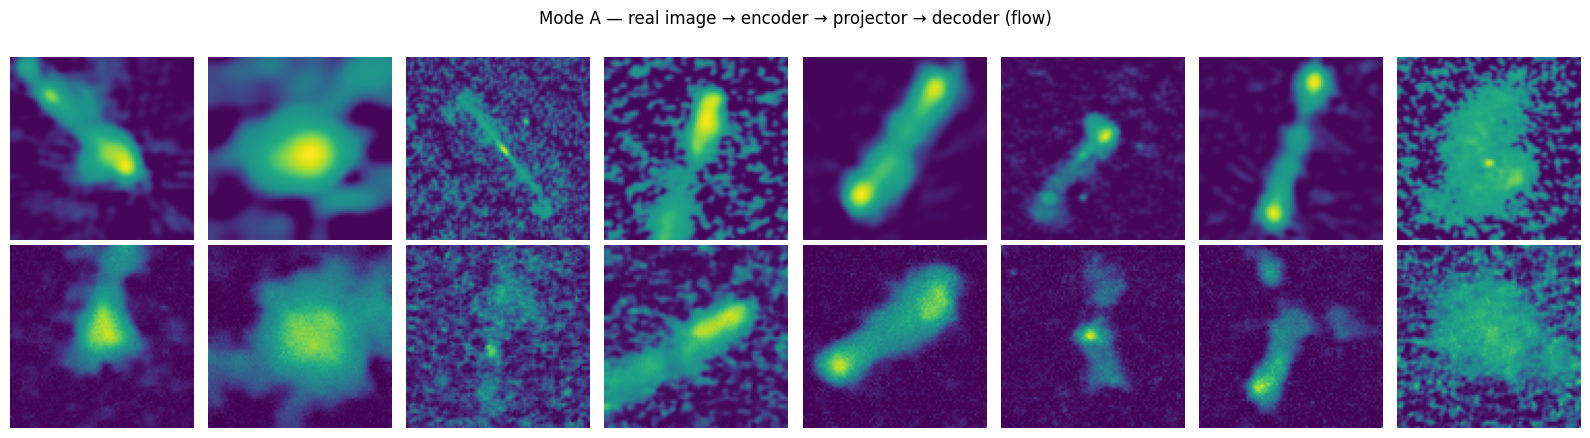

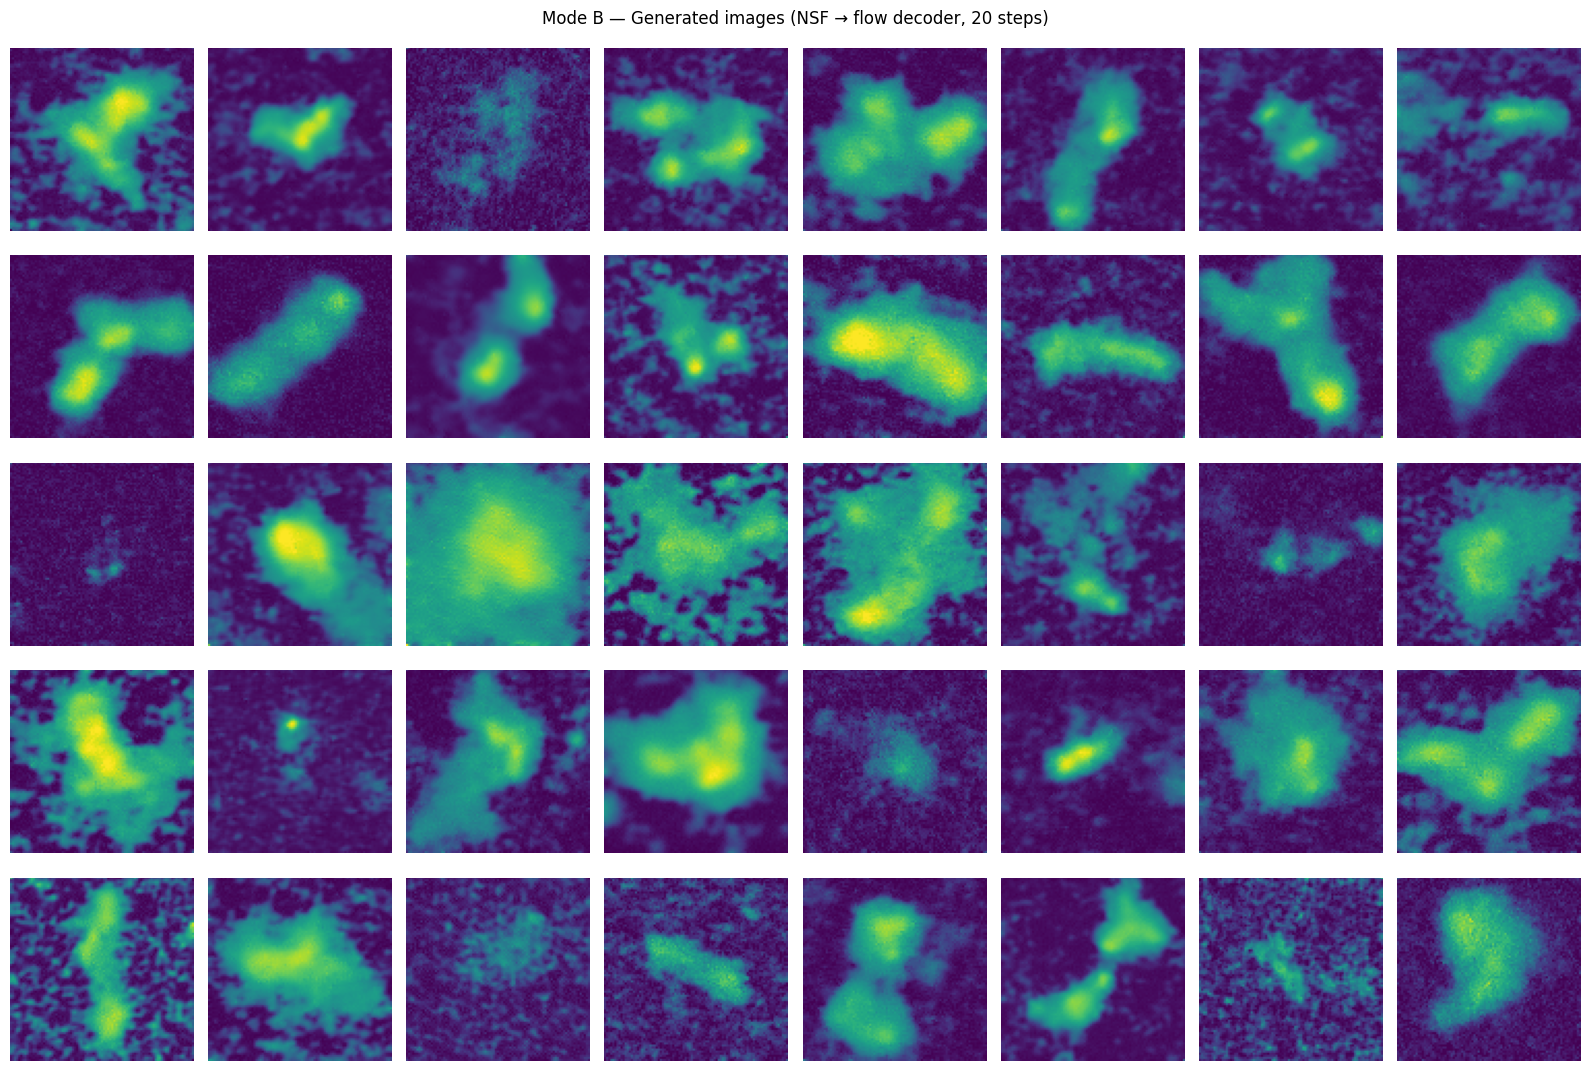

In [43]:
# Cell 8: Decoder usage modes
decoder.eval()
flow.eval()

DECODER_TYPE  = CONFIG.get("decoder_type", "flow")
FLOW_N_STEPS  = CONFIG.get("flow_n_steps", 20)
USE_PROJ      = CONFIG.get("use_projections", True)

def _decode(z):
    """Run decoder: z → image. Handles both decoder types."""
    if DECODER_TYPE == "flow":
        return decoder.sample(z, n_steps=FLOW_N_STEPS)   # returns (B,1,H,W) on z.device
    else:
        return decoder(z)   # returns (B,1,H,W) on z.device

# ─── Mode A: Reconstruct real images via encoder ──────────────────────────────
# Encode a real image → project (if use_projections) → decode → compare
n_recon = 8
sample_imgs = val_imgs[:n_recon].to(device)

with torch.no_grad():
    enc_out = byol.online_encoder(sample_imgs)
    if USE_PROJ:
        z_enc = byol.online_projector(enc_out)   # same space as decoder training
    else:
        z_enc = enc_out
    recon = _decode(z_enc).cpu()

fig, axes = plt.subplots(2, n_recon, figsize=(2 * n_recon, 4.5))
for i in range(n_recon):
    axes[0, i].imshow(sample_imgs[i, 0].cpu().numpy(), cmap="viridis", vmin=0, vmax=1)
    axes[0, i].axis("off")
    axes[1, i].imshow(recon[i, 0].numpy(), cmap="viridis", vmin=0, vmax=1)
    axes[1, i].axis("off")
axes[0, 0].set_ylabel("Original", fontsize=10)
axes[1, 0].set_ylabel("Decoded", fontsize=10)
plt.suptitle(f"Mode A — real image → encoder {'→ projector' if USE_PROJ else ''} → decoder ({DECODER_TYPE})")
plt.tight_layout()
plt.show()

# ─── Mode B: Generate from flow samples ──────────────────────────────────────
# Label y → NSF sample z → decode → image
def generate_images(label_vector, n_samples=8):
    flow.eval(); decoder.eval()
    y = torch.tensor(label_vector, dtype=torch.float32, device=device)
    y = y.unsqueeze(0).expand(n_samples, -1)
    with torch.no_grad():
        z = flow(y).sample()
        return _decode(z).cpu()

n_gen_per_class = 8
fig, axes = plt.subplots(n_labels, n_gen_per_class, figsize=(2 * n_gen_per_class, 2.2 * n_labels))
if n_labels == 1:
    axes = axes[None, :]

for row, name in enumerate(label_names_subset):
    label_vec = [0.0] * n_labels
    label_vec[row] = 1.0
    imgs_gen = generate_images(label_vec, n_samples=n_gen_per_class)
    for col in range(n_gen_per_class):
        axes[row, col].imshow(imgs_gen[col, 0].numpy(), cmap="viridis", vmin=0, vmax=1)
        axes[row, col].axis("off")
    axes[row, 0].set_ylabel(name, fontsize=9, rotation=0, labelpad=55, va="center")

plt.suptitle(f"Mode B — Generated images (NSF → {DECODER_TYPE} decoder, {FLOW_N_STEPS} steps)", fontsize=12)
plt.tight_layout()
plt.show()

## Cell 9: Visualizations

1. UMAP: real embeddings + flow-generated embeddings overlaid as stars  
2. Interpolation: two class conditions → interpolate z-space → decode

Fitting UMAP on train projections…


/users/mbredber/.venv/lib64/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


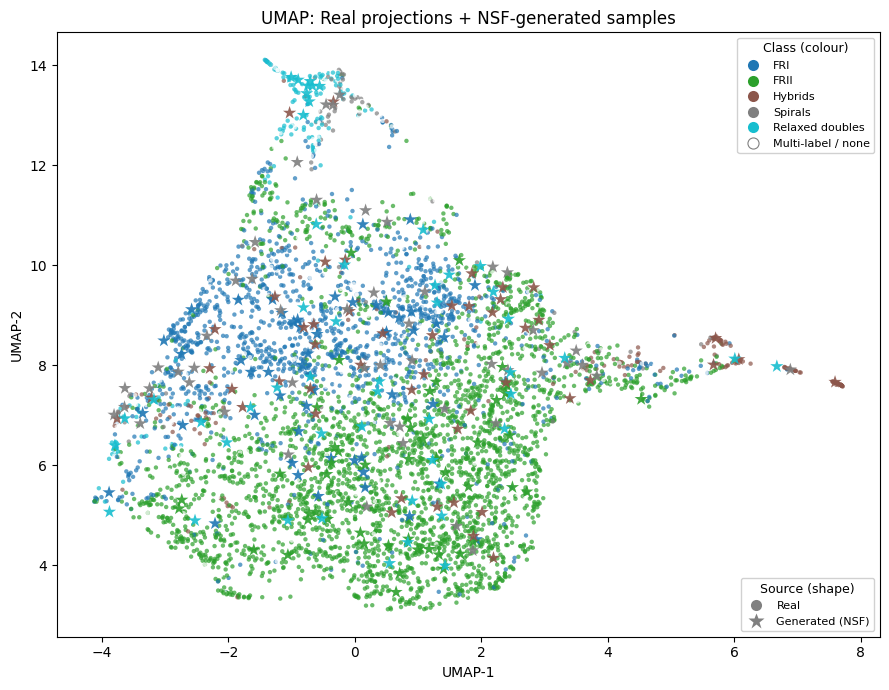

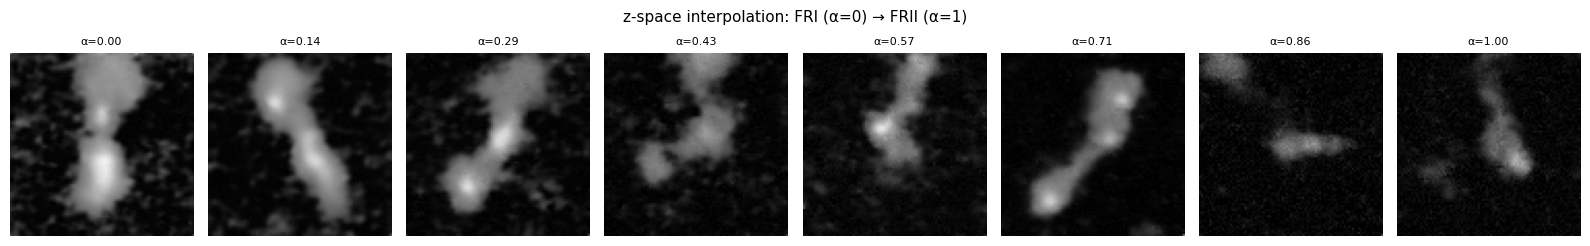

In [ ]:
# Cell 9: Visualizations
from matplotlib.lines import Line2D

feat_label = "projections" if USE_PROJECTIONS else "encoder features"
print(f"Fitting UMAP on train {feat_label}…")
reducer    = umap.UMAP(random_state=CONFIG["seed"], n_neighbors=15, min_dist=0.1)
umap_train = reducer.fit_transform(train_feats.numpy())   # (N_train, 2)

# Generate samples from the NSF for each class
n_gen_umap = max(50, 200 // n_labels)
flow.eval()
gen_zs, gen_class_ids = [], []
for row, name in enumerate(label_names_subset):
    label_vec = [0.0] * n_labels
    label_vec[row] = 1.0
    y = torch.tensor([label_vec], dtype=torch.float32, device=device).expand(n_gen_umap, -1)
    with torch.no_grad():
        z_gen = flow(y).sample().cpu().numpy()
    gen_zs.append(z_gen)
    gen_class_ids.extend([row] * n_gen_umap)

gen_zs_all    = np.concatenate(gen_zs, axis=0)
umap_gen      = reducer.transform(gen_zs_all)
gen_class_ids = np.array(gen_class_ids)

# ── Colour palette ────────────────────────────────────────────────────────────
cmap_cls     = plt.colormaps.get_cmap("tab10").resampled(n_labels)
class_colors = [cmap_cls(i) for i in range(n_labels)]

# ── Assign colours to real points ─────────────────────────────────────────────
real_colors = []
for i in range(len(train_y)):
    active = np.where(train_y[i] > 0.5)[0]
    real_colors.append(class_colors[active[0]] if len(active) == 1 else (1.0, 1.0, 1.0, 1.0))

# ── Plot ───────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 7))
ax.scatter(umap_train[:, 0], umap_train[:, 1],
           c=real_colors, s=10, alpha=0.7, edgecolors="none", marker="o", zorder=2)
for i, name in enumerate(label_names_subset):
    mask = gen_class_ids == i
    ax.scatter(umap_gen[mask, 0], umap_gen[mask, 1],
               color=class_colors[i], marker="*", s=100, alpha=0.9, edgecolors="none", zorder=3)

class_handles = [
    Line2D([0], [0], marker="o", linestyle="none",
           markerfacecolor=class_colors[i], markeredgecolor="none",
           markersize=8, label=label_names_subset[i])
    for i in range(n_labels)
]
class_handles.append(
    Line2D([0], [0], marker="o", linestyle="none",
           markerfacecolor="white", markeredgecolor="gray", markeredgewidth=0.8,
           markersize=8, label="Multi-label / none")
)
leg1 = ax.legend(handles=class_handles, title="Class (colour)",
                 loc="upper right", fontsize=8, title_fontsize=9, framealpha=0.9)
ax.add_artist(leg1)
ax.legend(handles=[
    Line2D([0], [0], marker="o", linestyle="none", markerfacecolor="gray",
           markeredgecolor="none", markersize=8, label="Real"),
    Line2D([0], [0], marker="*", linestyle="none", markerfacecolor="gray",
           markeredgecolor="none", markersize=12, label="Generated (NSF)"),
], title="Source (shape)", loc="lower right", fontsize=8, title_fontsize=9, framealpha=0.9)

ax.set_title(f"UMAP: Real {feat_label} + NSF-generated samples")
ax.set_xlabel("UMAP-1"); ax.set_ylabel("UMAP-2")
plt.tight_layout(); plt.show()

In [ ]:
if n_labels >= 2:
    name_a, name_b = label_names_subset[0], label_names_subset[1]
    label_a = [0.0] * n_labels;  label_a[0] = 1.0
    label_b = [0.0] * n_labels;  label_b[1] = 1.0

    ya = torch.tensor([label_a], dtype=torch.float32, device=device)
    yb = torch.tensor([label_b], dtype=torch.float32, device=device)
    with torch.no_grad():
        za = flow(ya).sample()
        zb = flow(yb).sample()

    n_steps  = 8
    alphas   = torch.linspace(0.0, 1.0, n_steps, device=device)
    z_interp = torch.stack([(1 - a) * za + a * zb for a in alphas]).squeeze(1)

    decoder.eval()
    imgs_interp = _decode(z_interp).cpu()   # handles both "cnn" and "flow" decoders

    fig, axes = plt.subplots(1, n_steps, figsize=(2 * n_steps, 2.5))
    for i, ax in enumerate(axes):
        ax.imshow(imgs_interp[i, 0].numpy(), cmap="gray", vmin=0, vmax=1)
        ax.set_title(f"α={alphas[i]:.2f}", fontsize=8)
        ax.axis("off")
    plt.suptitle(f"z-space interpolation: {name_a} (α=0) → {name_b} (α=1)", fontsize=11)
    plt.tight_layout(); plt.show()
else:
    print("Need ≥ 2 labels for interpolation — skipping.")